In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import sys
sys.path.append("/home/iscb/wolfson/hagairavid/ligand_aligner")
from utils.constants import NOT_ENOUGH_ATOMS_MESSAGE, TOO_MUCH_RESIDUES_MESSAGE, LIGAND_RESIDUE_IS_MISSED_MESSAGE, N_ATOMS_RATIO_MESSAGE


In [3]:
prefix = "2024-07-09_17-43-50_2720.csv"
directory = "/home/iscb/wolfson/hagairavid/ligand_aligner/results/alignment_temp_results/"
matching_files = [f for f in os.listdir(directory) if f.startswith(prefix)]

if matching_files:
    latest_file = max(matching_files, key=lambda x: os.path.getmtime(os.path.join(directory, x)))
    file_path = os.path.join(directory, latest_file)
    print("Latest file:", file_path)
else:
    print("No matching files found.")
df = pd.read_csv(file_path)


df['coverage'] = df['coverage'].astype(str)
df['rmse'] = df['rmse'].astype(str)

def str_to_list_of_lists(s):
    try:
        tuple_of_lists = ast.literal_eval(s)
        list_of_lists = [list(sublist) for sublist in tuple_of_lists]
        return list_of_lists
    except:
        return []
def str_to_list(s):
    try:
        tuple_of_lists = ast.literal_eval(s)
        # list_of_lists = list(sublist)
        return tuple_of_lists
    except:
        return []

df['coverage'] = df['coverage'].apply(str_to_list_of_lists)
df['rmse'] = df['rmse'].apply(str_to_list_of_lists)
df['ref_ligand_n_atoms'] = df['ref_ligand_n_atoms'].apply(str_to_list)


Latest file: /home/iscb/wolfson/hagairavid/ligand_alligner/results/alignment_temp_results/2024-07-09_17-43-50_2720.csv


In [4]:
df.head()['translations'][0]


'[[[14.282418251037598, 62.788368225097656, -5.382698059082031, 1.0]]]'

## Number of transformations

Total pairs with at least one transformation: (1189, 25)


Text(0.5, 1.0, 'Number of transformations')

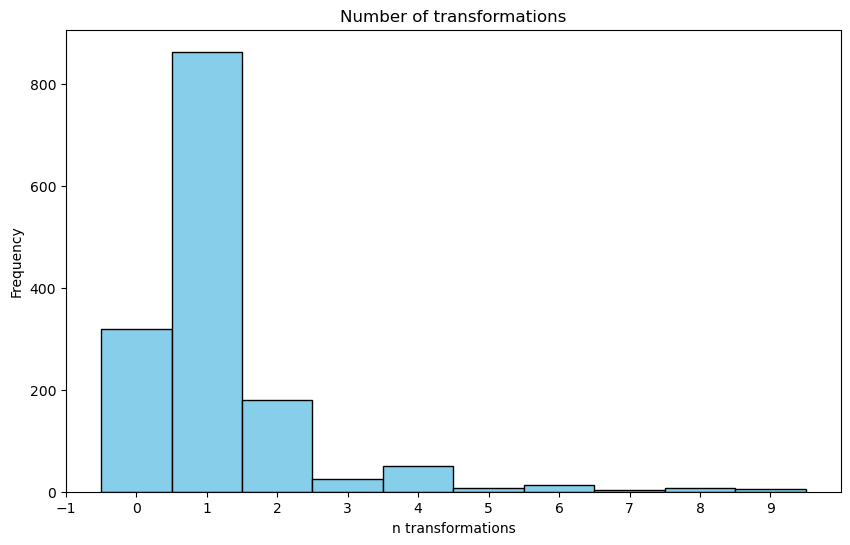

In [5]:
print(f"Total pairs with at least one transformation: {df[df['n_transformations'] > 0].shape}")
filtered_df = df[df['n_transformations'] < 10]
plt.figure(figsize=(10, 6))
plt.hist(filtered_df['n_transformations'], bins= int(filtered_df['n_transformations'].max()) + 1, range=(0-0.5, filtered_df['n_transformations'].max()+0.5), color='skyblue', edgecolor='black')
plt.xticks(filtered_df['n_transformations'].unique())

# Adding labels and title

plt.xlabel('n transformations')
plt.ylabel('Frequency')
plt.title('Number of transformations')

#### Pairs with 2 clusters for specific ligand residues

In [6]:
def has_2_trans(values):
    for val in values:
        if len(val) == 2:
            return True
    return False

has_two_clusters = df['coverage'].apply(has_2_trans)
print(has_two_clusters.sum())
df[has_two_clusters].head()

36


,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,...,n_residues_mov_ligand,failure_message,DaliAligner_rotations,DaliAligner_translations,DaliAligner_protein_rmsd,DaliAligner_rmsd,TMaligner_rotations,TMaligner_translations,TMaligner_protein_rmsd,TMaligner_rmsd
40,ADP,1htw,4j8f,A,A,2,"[[[[0.08246075361967087, 0.6793885231018066, -...","[[[10.866772651672363, -14.522834777832031, 27...","[[0.11717182299164305, 0.27134895837575734]]","[[0.4074074074074074, 0.5185185185185185]]",...,1,NaN,[],[],[],NaN,"[[[0.6937503412491584, -0.6679019009224276, 0....","[[21.855117146955433, 31.477710811856582, 6.58...",0.356710,27.201412
253,PGA,1te2,6bve,A,A,2,"[[[[0.11381462216377258, 0.8791065812110901, -...","[[[38.16083908081055, 47.54408645629883, -2.65...","[[0.19473885426007675, 0.15534755391603317]]","[[0.5555555555555556, 0.5555555555555556]]",...,1,NaN,[],[],[],NaN,"[[[0.7950849690926116, -0.3736325029605197, 0....","[[34.24006852668771, 50.75736625516405, 7.7840...",0.358563,NaN
407,NAD,4go4,6e2a,A,A,2,"[[[[-0.047161348164081573, 0.8672067523002625,...","[[[36.401790618896484, -43.99787902832031, 11....","[[0.20991230139948464, 0.2260630597079265]]","[[0.36363636363636365, 0.3409090909090909]]",...,1,NaN,[],[],[],NaN,"[[[0.12511427248626192, 0.9292347818145278, -0...","[[68.76815698546726, -53.12016127303478, -17.0...",0.245071,13.908374
547,FAD,5n1t,6cmz,A,A,3,"[[[[0.2541024088859558, -0.3149361312389374, 0...","[[[16.584623336791992, 36.7116813659668, 9.510...","[[0.29508161650527986], [0.10587405939136577, ...","[[0.9245283018867925], [0.37735849056603776, 0...",...,2,NaN,"[[[0.3189090384970173, -0.39467580009501335, 0...","[[17.121059, 35.992813, 11.730628]]",2.9,NaN,"[[[0.3263320385064682, -0.39939175891237316, 0...","[[16.47791112944723, 36.441646859977496, 12.03...",0.710095,NaN
562,FAD,2gpj,4emj,A,A,2,"[[[[0.0018790927715599537, -0.8462268114089966...","[[[9.429553031921387, 57.83736038208008, -15.2...","[[0.1578325323602706, 0.2643247902082455]]","[[0.37735849056603776, 0.32075471698113206]]",...,1,NaN,"[[[-0.8261992155042768, 0.45867325175824114, 0...","[[39.453865, 22.244844, -2.777478]]",3.1,11.464262,"[[[-0.22918278537424444, -0.6698988059020129, ...","[[10.70911147547836, 49.44963741794853, -11.37...",0.343449,15.363340


In [ ]:
# filtered_df = df[df["failure message"].isna()]
df[df["n_transformations"] == 0]["failure message"].value_counts()
no_trans = df[df["n_transformations"] == 0]
print(no_trans[no_trans["failure message"].isna()].shape)
no_trans[no_trans["failure message"].isna()].head()

KeyError: 'failure message'

### Failres

/tmp/ipykernel_1635783/3067064633.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[df['cath_degree'] < 1]['failure_message'].dropna(), data=df, palette='viridis')


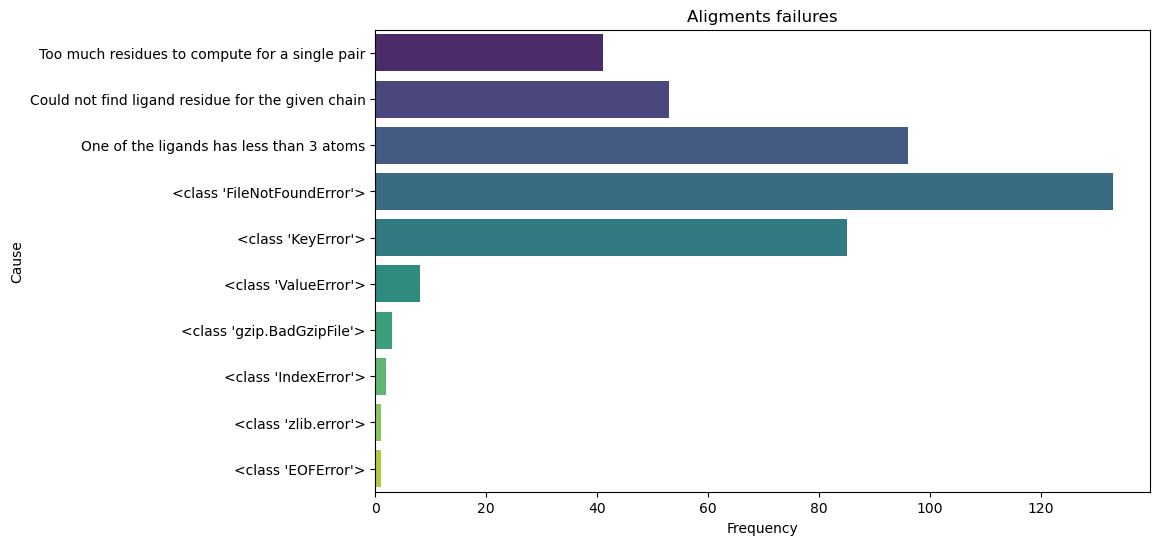

In [ ]:
# print(df[df['n_transformations'] < 1].columns)
plt.figure(figsize=(10, 6)) 
sns.countplot(y=df[df['cath_degree'] < 1]['failure_message'].dropna(), data=df, palette='viridis')
plt.xlabel('Frequency')
plt.ylabel('Cause')
plt.title('Aligments failures')
plt.show()

In [ ]:
df[df['failure message'] == N_ATOMS_RATIO_MESSAGE].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
195,CNA,1a26,6hxs,A,A,0.0,(),(),[],[],0,[27],[44],The lengths of the lignads differ significantl...
212,NAP,5gsn,8u2w,A,A,0.0,(),(),[],[],0,[48],[31],The lengths of the lignads differ significantl...
385,COA,3f5o,7s3u,A,A,0.0,(),(),[],[],0,[38],[48],The lengths of the lignads differ significantl...
386,COA,5kf2,8p5s,A,A,0.0,(),(),[],[],0,[23],[31],The lengths of the lignads differ significantl...
388,COA,1y7u,6b3t,A,A,0.0,(),(),[],[],1,[48],[39],The lengths of the lignads differ significantl...


In [ ]:
df[df['failure message'] == NOT_ENOUGH_ATOMS_MESSAGE].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
111,CO,2ew5,3s8k,A,A,0.0,(),(),[],[],0,[1],"[1, 1]",One of the ligands has less than 3 atoms
112,CO,2ywr,6cgy,A,A,0.0,(),(),[],[],1,"[1, 1, 1, 1]","[1, 1]",One of the ligands has less than 3 atoms
113,CO,2uzp,3n5f,A,A,0.0,(),(),[],[],0,[1],[1],One of the ligands has less than 3 atoms
114,CO,1gwm,7etl,A,A,0.0,(),(),[],[],0,[1],[1],One of the ligands has less than 3 atoms
115,CO,2os3,4wzx,A,A,0.0,(),(),[],[],0,[1],[1],One of the ligands has less than 3 atoms


In [ ]:
df[df['failure message'] == LIGAND_RESIDUE_IS_MISSED_MESSAGE].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
64,HEM,1drm,1jju,A,B,0.0,(),(),[],[],0,[43],[],Could not find ligand residue for the given chain
84,NaN,3r0x,4zla,A,A,0.0,(),(),[],[],2,[],[],Could not find ligand residue for the given chain
85,NaN,1c9o,8hir,A,A,0.0,(),(),[],[],0,[],[],Could not find ligand residue for the given chain
86,NaN,3pak,4zla,A,A,0.0,(),(),[],[],1,[],[],Could not find ligand residue for the given chain
87,NaN,5nv9,8cv2,A,A,0.0,(),(),[],[],0,[],[],Could not find ligand residue for the given chain


In [ ]:
df[df['failure message'] == TOO_MUCH_RESIDUES_MESSAGE].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
21,ASN,2dqn,6pa3,A,A,0.0,(),(),[],[],0,"[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",Too much residues to compute for a single pair
22,ASN,2cg4,6pa3,A,A,0.0,(),(),[],[],0,"[8, 8, 8, 8, 9]","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",Too much residues to compute for a single pair
23,ASN,3h0l,6pa3,A,A,0.0,(),(),[],[],0,"[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",Too much residues to compute for a single pair
24,ASN,11as,6ior,A,A,0.0,(),(),[],[],2,"[8, 8, 8, 9]","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9]",Too much residues to compute for a single pair
25,ASN,11as,3kxa,A,A,0.0,(),(),[],[],0,"[8, 8, 8, 9]","[8, 8, 8, 8, 8, 9]",Too much residues to compute for a single pair


## CATH analsys:


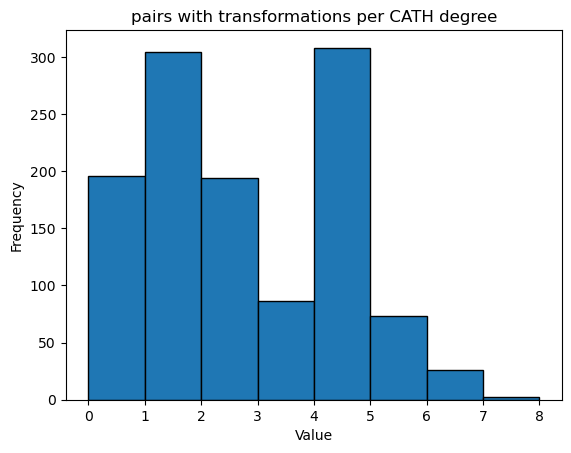

In [ ]:
# Plotting the histogram
plt.hist(df[df['n_transformations'] > 0]['cath_degree'], bins=8, edgecolor='black')

# Adding title and labels
plt.title('pairs with transformations per CATH degree')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Display the plot
plt.show()

In [ ]:
# Plotting the histogram
plt.hist(df['ref_ligand_n_atoms'].map(max), bins=8, edgecolor='black')

# Adding title and labels
plt.title('pairs with transformations per CATH degree')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Display the plot
plt.show()

ValueError: max() arg is an empty sequence

Text(0.5, 1.0, 'mean of (1-mse) + coverage')

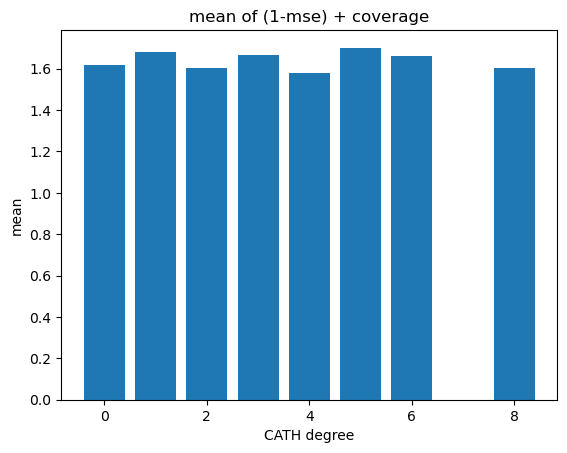

In [ ]:

def sum_per_row(lst):
    return sum(lst)  if lst else None

def calculate_gap(row):
    ret = []
    for coverage, rmse in zip(row['coverage'], row['rmse']):
        for i in range(len(coverage)):
            ret.append(coverage[i] + (1- rmse[i]))
    return ret

df['gap'] = df.apply(calculate_gap, axis=1)
df['total_gap'] = df['gap'].apply(sum_per_row)
mean_values = df.groupby('cath_degree')['total_gap'].sum() / df.groupby('cath_degree')['n_transformations'].sum()

# Step 2: Create the histogram
plt.bar(mean_values.index, mean_values.values)
plt.xlabel('CATH degree')
plt.ylabel('mean of (1-mse) + coverage')
plt.title('RANSAC alignment score VS CATH degree')